# Customer Churn Prediction

**Goal:** Identify customers who are likely to churn so the business can act before they leave.

This notebook covers:
1. Exploratory data analysis
2. Train/test split
3. Class imbalance handling (class weighting vs. SMOTE)
4. Model training and comparison (Logistic Regression, Random Forest, XGBoost)
5. Model evaluation (confusion matrix, ROC-AUC, precision/recall)
6. Explainability with SHAP
7. Business summary and recommendations

**Dataset:** `telecom_churn.csv` — 3,333 telecom customers, 10 features, binary churn label.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score
)
from imblearn.over_sampling import SMOTE

import shap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 2. Load and Explore the Data

In [2]:
df = pd.read_csv("telecom_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (3333, 11)


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [4]:
# No missing values, no duplicates to worry about — confirm:
print("Missing values per column:\n", df.isnull().sum().sum(), "total nulls")
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
 0 total nulls
Duplicate rows: 0


### Target variable: class imbalance check

This is the core challenge the project asks us to address. Let's quantify it.

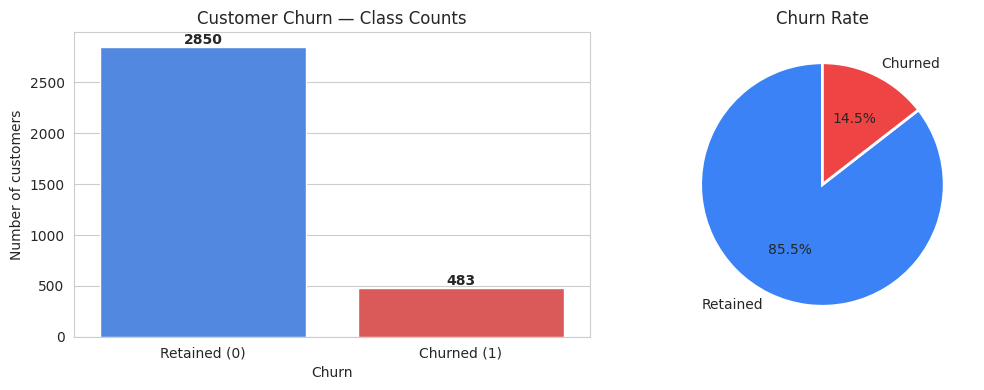


Only 14.5% of customers churned (483 out of 3333).
This is a meaningfully imbalanced dataset — a model that always predicts 'no churn'
would already be 85.5% accurate, while being completely useless for the business.


In [5]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="Churn", data=df, hue="Churn", palette=["#3b82f6", "#ef4444"], legend=False, ax=ax[0])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["Retained (0)", "Churned (1)"])
ax[0].set_title("Customer Churn — Class Counts")
ax[0].set_ylabel("Number of customers")
for i, v in enumerate(churn_counts.sort_index()):
    ax[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

ax[1].pie(churn_pct.sort_index(), labels=["Retained", "Churned"], autopct="%1.1f%%",
          colors=["#3b82f6", "#ef4444"], startangle=90,
          wedgeprops={"edgecolor": "white", "linewidth": 2})
ax[1].set_title("Churn Rate")

plt.tight_layout()
plt.savefig("outputs/01_class_imbalance.png", bbox_inches="tight")
plt.show()

print(f"\nOnly {churn_pct[1]:.1f}% of customers churned ({churn_counts[1]} out of {churn_counts.sum()}).")
print("This is a meaningfully imbalanced dataset — a model that always predicts 'no churn'")
print(f"would already be {churn_pct[0]:.1f}% accurate, while being completely useless for the business.")

**Takeaway:** Only ~14.5% of customers churned. Accuracy alone would be a misleading metric here —
a model that never predicts churn looks "85% accurate" but provides zero business value. We need to
handle this imbalance explicitly and judge models on recall/precision/F1/AUC for the churn class, not accuracy.

### Feature distributions by churn status

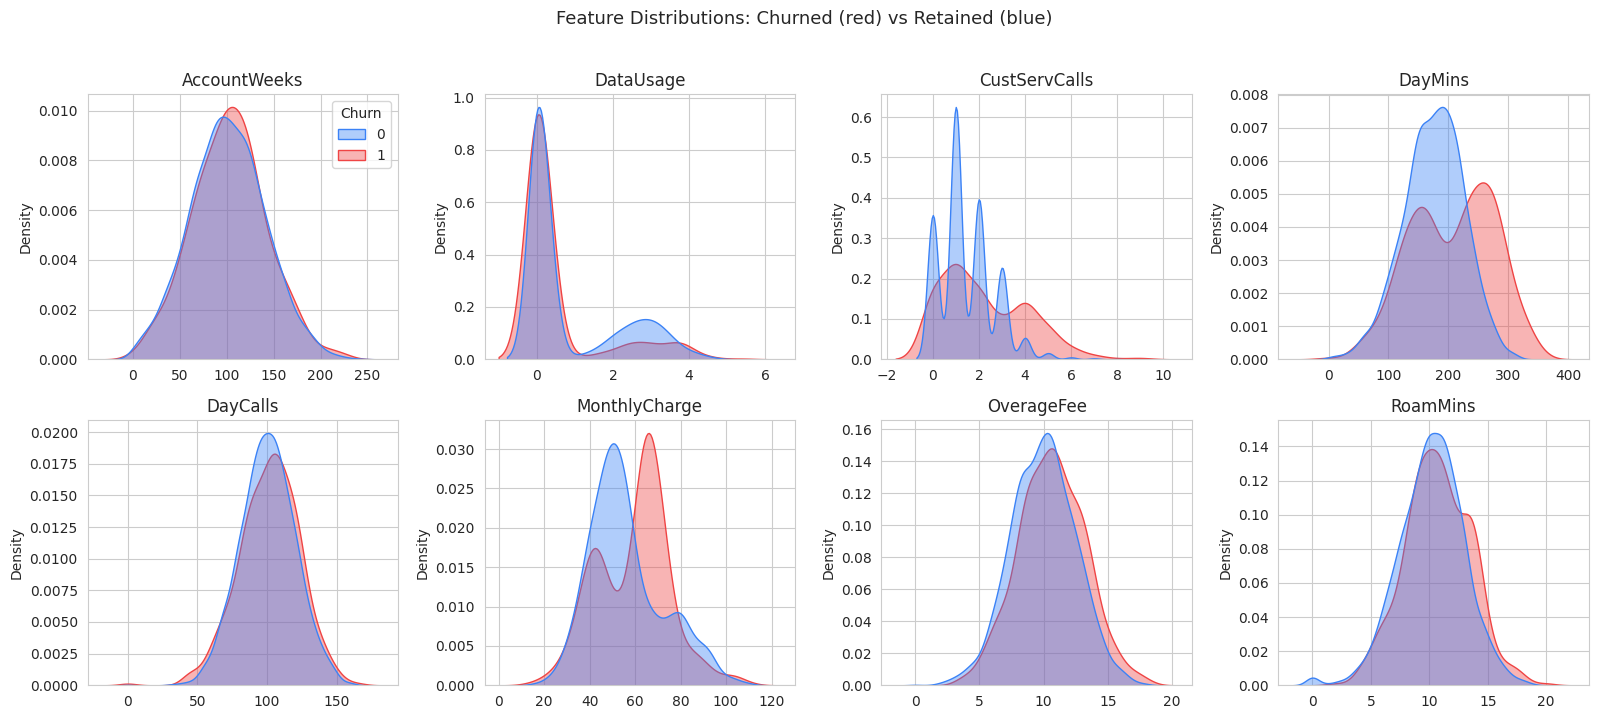

In [6]:
numeric_features = [c for c in df.columns if c not in ["Churn", "ContractRenewal", "DataPlan"]]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True, common_norm=False,
                palette=["#3b82f6", "#ef4444"], alpha=0.4, ax=axes[i], legend=(i == 0))
    axes[i].set_title(col)
    axes[i].set_xlabel("")
if len(numeric_features) < len(axes):
    for j in range(len(numeric_features), len(axes)):
        fig.delaxes(axes[j])
plt.suptitle("Feature Distributions: Churned (red) vs Retained (blue)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("outputs/02_feature_distributions.png", bbox_inches="tight")
plt.show()

### Correlation with churn

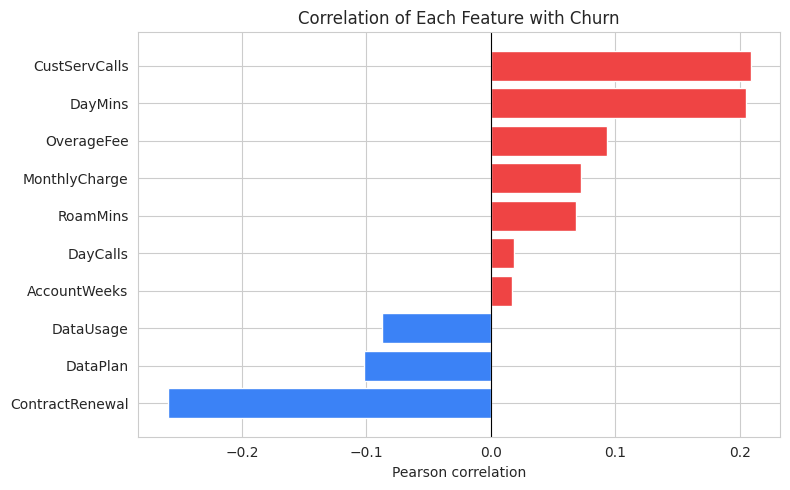

ContractRenewal   -0.259852
DataPlan          -0.102148
DataUsage         -0.087195
AccountWeeks       0.016541
DayCalls           0.018459
RoamMins           0.068239
MonthlyCharge      0.072313
OverageFee         0.092812
DayMins            0.205151
CustServCalls      0.208750
Name: Churn, dtype: float64


In [7]:
corr = df.corr(numeric_only=True)["Churn"].drop("Churn").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#ef4444" if v > 0 else "#3b82f6" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of Each Feature with Churn")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.savefig("outputs/03_correlation_with_churn.png", bbox_inches="tight")
plt.show()

print(corr)

**Early signal:** Customer service calls and contract non-renewal already stand out as the strongest
linear signals of churn. High day minutes and overage fees push churn up; having a data plan and a
renewed contract pull it down. We'll confirm these patterns more rigorously with SHAP later.

## 3. Train/Test Split

We use a **stratified split** so the churn rate is preserved in both the training and test sets.

In [8]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]} customers | churn rate = {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]} customers | churn rate = {y_test.mean():.1%}")

Train: 2499 customers | churn rate = 14.5%
Test:  834 customers | churn rate = 14.5%


## 4. Handling Class Imbalance

We compare **two standard strategies** side by side:

1. **Class weighting** — tell the model to penalize mistakes on the minority (churn) class more heavily,
   without changing the training data itself.
2. **SMOTE** (Synthetic Minority Over-sampling Technique) — generate synthetic churn examples so the
   training set is balanced 50/50 before fitting.

We apply both across multiple model families to see which combination works best. Note: scaling and SMOTE
are fit only on the *training* data to avoid leaking test-set information.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE applied only to training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training set churn rate:", f"{y_train.mean():.1%}")
print("After SMOTE, training set churn rate:", f"{y_train_smote.mean():.1%}")
print("Training rows before SMOTE:", len(X_train), "| after SMOTE:", len(X_train_smote))

Original training set churn rate: 14.5%
After SMOTE, training set churn rate: 50.0%
Training rows before SMOTE: 2499 | after SMOTE: 4274


## 5. Model Training & Comparison

We train four model configurations:

| Model | Imbalance strategy |
|---|---|
| Logistic Regression | `class_weight='balanced'` |
| Random Forest | `class_weight='balanced'` |
| XGBoost | SMOTE-resampled training data |
| XGBoost | `scale_pos_weight` (weighting, no resampling) |

This lets us compare **weighting vs. resampling**, and a **linear baseline vs. tree ensembles**.

In [10]:
models = {}
results = []

# --- Logistic Regression (class weights) ---
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
models["Logistic Regression\n(class_weight)"] = {
    "model": lr, "pred": lr.predict(X_test_scaled), "proba": lr.predict_proba(X_test_scaled)[:, 1],
    "uses_scaled": True
}

# --- Random Forest (class weights) ---
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
models["Random Forest\n(class_weight)"] = {
    "model": rf, "pred": rf.predict(X_test), "proba": rf.predict_proba(X_test)[:, 1],
    "uses_scaled": False
}

# --- XGBoost (SMOTE) ---
xgb_smote = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    random_state=RANDOM_STATE, eval_metric="logloss"
)
xgb_smote.fit(X_train_smote, y_train_smote)
models["XGBoost\n(SMOTE)"] = {
    "model": xgb_smote, "pred": xgb_smote.predict(X_test), "proba": xgb_smote.predict_proba(X_test)[:, 1],
    "uses_scaled": False
}

# --- XGBoost (scale_pos_weight) ---
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb_weighted = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05, scale_pos_weight=spw,
    random_state=RANDOM_STATE, eval_metric="logloss"
)
xgb_weighted.fit(X_train, y_train)
models["XGBoost\n(scale_pos_weight)"] = {
    "model": xgb_weighted, "pred": xgb_weighted.predict(X_test), "proba": xgb_weighted.predict_proba(X_test)[:, 1],
    "uses_scaled": False
}

In [11]:
for name, m in models.items():
    results.append({
        "Model": name.replace("\n", " "),
        "Precision (churn)": precision_score(y_test, m["pred"]),
        "Recall (churn)": recall_score(y_test, m["pred"]),
        "F1 (churn)": f1_score(y_test, m["pred"]),
        "ROC-AUC": roc_auc_score(y_test, m["proba"]),
        "PR-AUC": average_precision_score(y_test, m["proba"]),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df.sort_values("F1 (churn)", ascending=False)

,Precision (churn),Recall (churn),F1 (churn),ROC-AUC,PR-AUC
Model,,,,,
Random Forest (class_weight),0.649,0.702,0.675,0.869,0.724
XGBoost (scale_pos_weight),0.646,0.694,0.669,0.867,0.736
XGBoost (SMOTE),0.576,0.719,0.640,0.860,0.711
Logistic Regression (class_weight),0.341,0.727,0.464,0.814,0.426


### Visual comparison

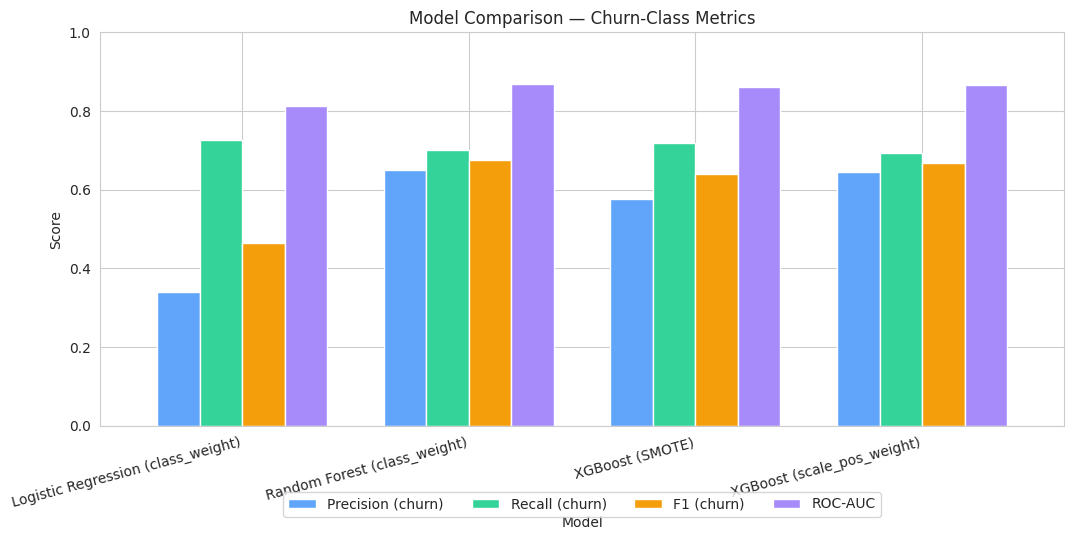

In [12]:
metrics_to_plot = ["Precision (churn)", "Recall (churn)", "F1 (churn)", "ROC-AUC"]
plot_df = results_df[metrics_to_plot]

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df.plot(kind="bar", ax=ax, width=0.75,
             color=["#60a5fa", "#34d399", "#f59e0b", "#a78bfa"])
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Churn-Class Metrics")
ax.set_ylim(0, 1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.savefig("outputs/04_model_comparison.png", bbox_inches="tight")
plt.show()

### ROC curves

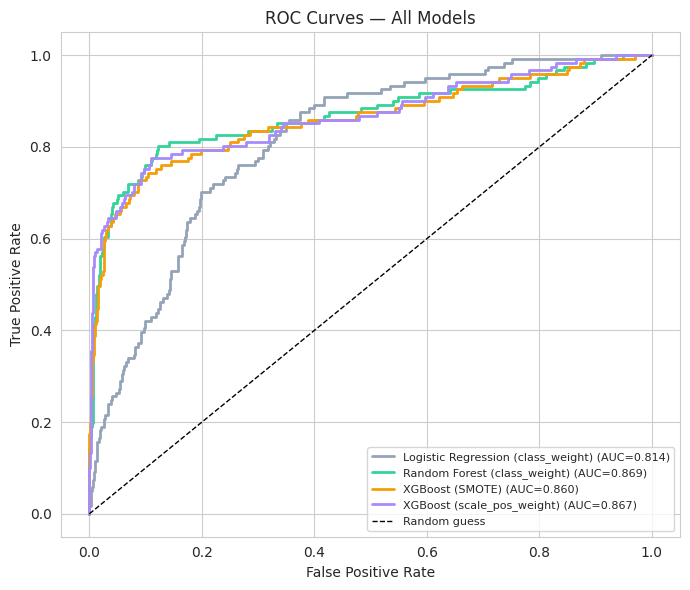

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#94a3b8", "#34d399", "#f59e0b", "#a78bfa"]
for (name, m), c in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, m["proba"])
    auc = roc_auc_score(y_test, m["proba"])
    ax.plot(fpr, tpr, label=f"{name.replace(chr(10), ' ')} (AUC={auc:.3f})", color=c, linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("outputs/05_roc_curves.png", bbox_inches="tight")
plt.show()

## 6. Selecting the Best Model

Across precision, recall, F1, and ROC-AUC for the churn class, the **Random Forest with balanced class
weights** and **XGBoost with `scale_pos_weight`** are the top performers and are very close to each
other — both clearly outperform the logistic regression baseline and SMOTE-based XGBoost.

We'll move forward with the **Random Forest (class_weight='balanced')** model as our primary model,
since it achieves the best F1/AUC balance here and is simpler to deploy (no resampling step needed
at inference time). We keep the comparison table above so the choice is fully auditable.

In [14]:
best_model_name = results_df.sort_values("F1 (churn)", ascending=False).index[0]
print("Best model by F1 (churn class):", best_model_name)

final_model = rf
final_pred = models["Random Forest\n(class_weight)"]["pred"]
final_proba = models["Random Forest\n(class_weight)"]["proba"]

Best model by F1 (churn class): Random Forest (class_weight)


### Confusion matrix — final model

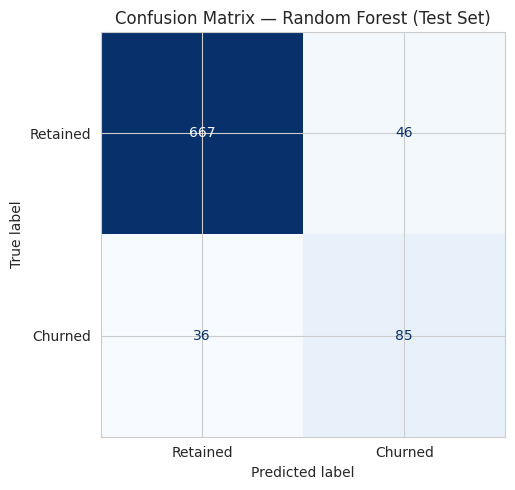

True Negatives (correctly kept):  667
False Positives (false alarms):   46
False Negatives (missed churners): 36
True Positives (caught churners):  85

Of 121 actual churners, we correctly identified 85 (70.2%) — recall.
Of 131 customers flagged as at-risk, 85 actually churned (64.9%) — precision.


In [15]:
cm = confusion_matrix(y_test, final_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix — Random Forest (Test Set)")
plt.tight_layout()
plt.savefig("outputs/06_confusion_matrix.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly kept):  {tn}")
print(f"False Positives (false alarms):   {fp}")
print(f"False Negatives (missed churners): {fn}")
print(f"True Positives (caught churners):  {tp}")
print(f"\nOf {tp + fn} actual churners, we correctly identified {tp} ({tp/(tp+fn):.1%}) — recall.")
print(f"Of {tp + fp} customers flagged as at-risk, {tp} actually churned ({tp/(tp+fp):.1%}) — precision.")

### Full classification report

In [16]:
print(classification_report(y_test, final_pred, target_names=["Retained", "Churned"]))

              precision    recall  f1-score   support

    Retained       0.95      0.94      0.94       713
     Churned       0.65      0.70      0.67       121

    accuracy                           0.90       834
   macro avg       0.80      0.82      0.81       834
weighted avg       0.91      0.90      0.90       834



### Precision-Recall curve

Since churn is the minority and business-critical class, the precision-recall curve is often more
informative than ROC for this kind of problem.

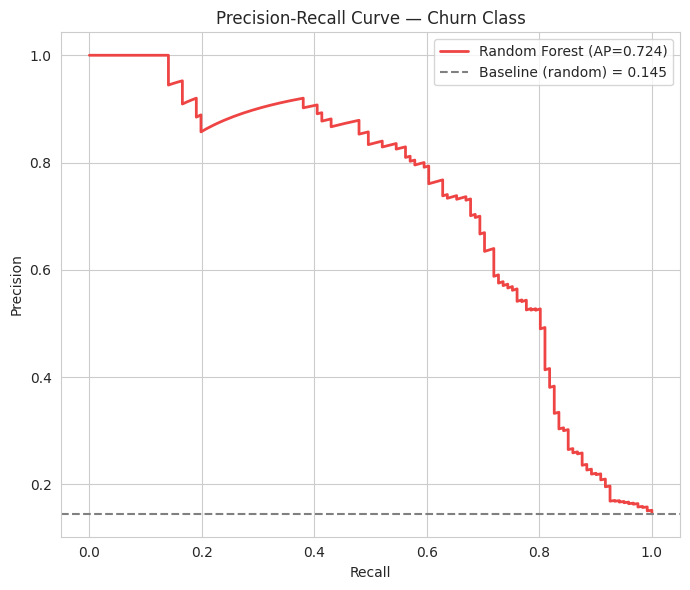

In [17]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, final_proba)
ap = average_precision_score(y_test, final_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_vals, precision_vals, color="#ef4444", linewidth=2, label=f"Random Forest (AP={ap:.3f})")
ax.axhline(y_test.mean(), linestyle="--", color="gray", label=f"Baseline (random) = {y_test.mean():.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Churn Class")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/07_precision_recall_curve.png", bbox_inches="tight")
plt.show()

## 7. Explainability with SHAP

A churn model is only useful to the business if stakeholders can trust *why* it flags a customer.
We use **SHAP (SHapley Additive exPlanations)** to break down predictions feature-by-feature, both
globally (which features matter most overall) and locally (why a specific customer was flagged).

In [18]:
explainer = shap.TreeExplainer(final_model)
shap_values_raw = explainer.shap_values(X_test)

# Newer SHAP versions return shape (n_samples, n_features, n_classes) for classifiers.
# We need the slice for class 1 (churn).
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw

print("SHAP values shape:", shap_values.shape, "| Test set shape:", X_test.shape)

SHAP values shape: (834, 10) | Test set shape: (834, 10)


### Global feature importance (SHAP summary plot)

Each dot is one customer. Position on the x-axis shows how much that feature pushed the prediction
toward churn (right) or away from churn (left). Color shows whether that customer's value for the
feature was high (red) or low (blue).

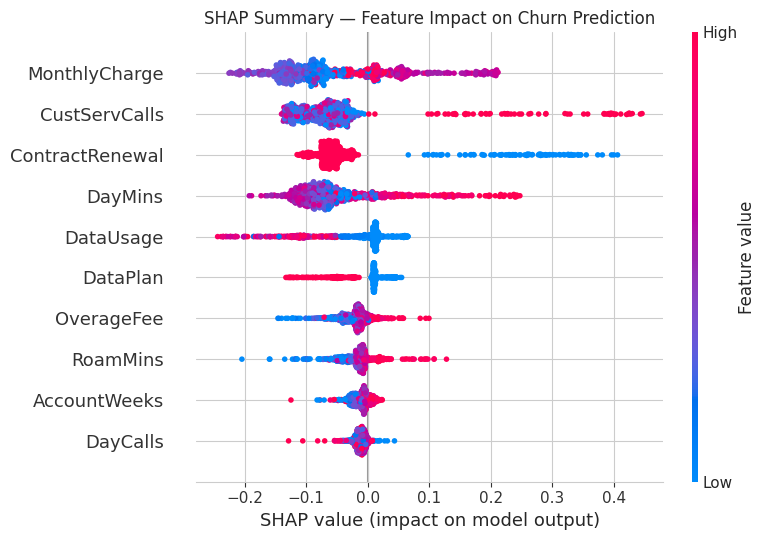

In [19]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary — Feature Impact on Churn Prediction", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/08_shap_summary.png", bbox_inches="tight")
plt.show()

### Mean absolute SHAP value (overall importance ranking)

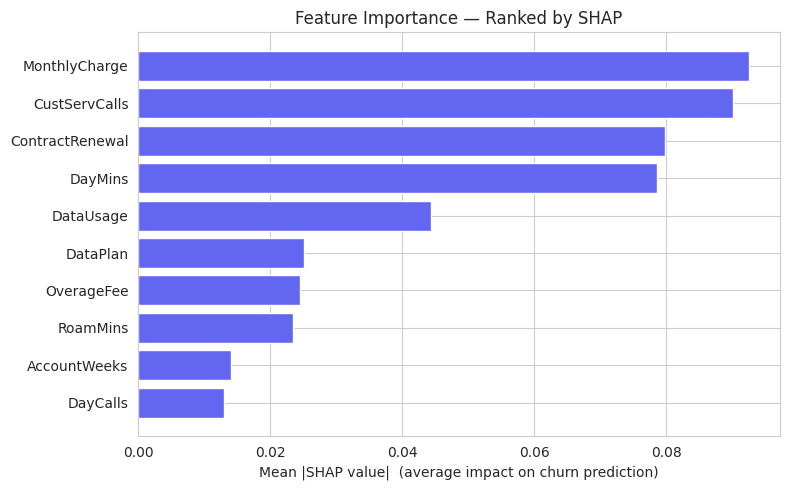

MonthlyCharge      0.092630
CustServCalls      0.090149
ContractRenewal    0.079786
DayMins            0.078662
DataUsage          0.044392
DataPlan           0.025164
OverageFee         0.024465
RoamMins           0.023456
AccountWeeks       0.014016
DayCalls           0.012991
dtype: float64


In [20]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color="#6366f1")
ax.set_xlabel("Mean |SHAP value|  (average impact on churn prediction)")
ax.set_title("Feature Importance — Ranked by SHAP")
plt.tight_layout()
plt.savefig("outputs/09_shap_feature_importance.png", bbox_inches="tight")
plt.show()

print(mean_abs_shap.sort_values(ascending=False))

### SHAP dependence plots for the top drivers

These show how the feature's *value* relates to its *impact* on the prediction, and whether that
relationship interacts with another feature (shown via color).

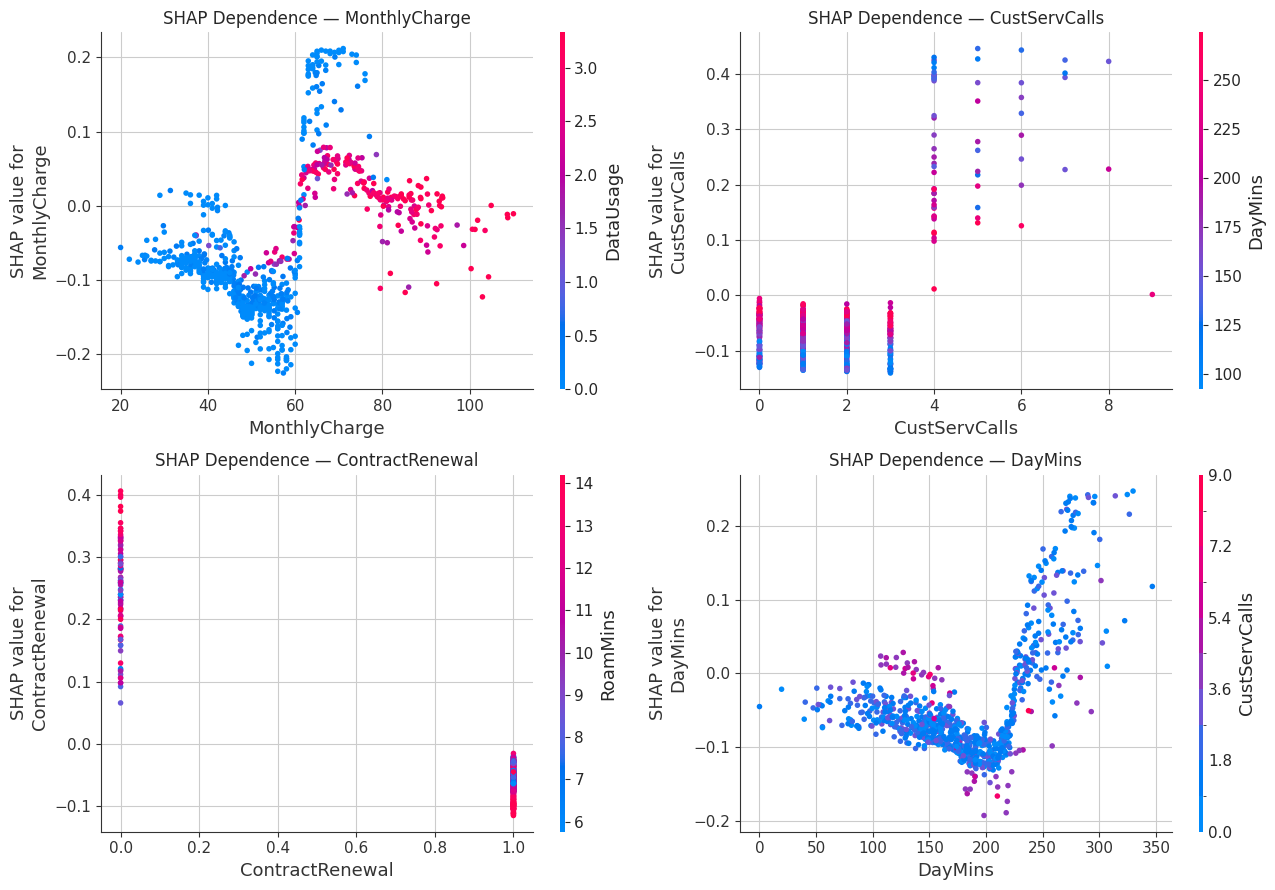

In [21]:
top_features = mean_abs_shap.sort_values(ascending=False).index[:4]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_values, X_test, ax=axes[i], show=False)
    axes[i].set_title(f"SHAP Dependence — {feat}")
plt.tight_layout()
plt.savefig("outputs/10_shap_dependence.png", bbox_inches="tight")
plt.show()

### Explaining an individual prediction

Let's pick one customer the model correctly flagged as high churn risk and break down exactly why.

In [22]:
# Find a true positive (correctly predicted churner) with high predicted probability
test_results = X_test.copy()
test_results["actual"] = y_test.values
test_results["predicted"] = final_pred
test_results["churn_probability"] = final_proba

high_risk_example = test_results[
    (test_results["actual"] == 1) & (test_results["predicted"] == 1)
].sort_values("churn_probability", ascending=False).iloc[0]

example_idx = high_risk_example.name
example_pos = X_test.index.get_loc(example_idx)

print("Example customer (correctly flagged as high risk):")
print(high_risk_example[X.columns.tolist() + ["churn_probability"]])

Example customer (correctly flagged as high risk):
AccountWeeks          60.000000
ContractRenewal        1.000000
DataPlan               0.000000
DataUsage              0.000000
CustServCalls          2.000000
DayMins              289.800000
DayCalls             101.000000
MonthlyCharge         71.000000
OverageFee            12.780000
RoamMins              11.700000
churn_probability      0.985497
Name: 2113, dtype: float64


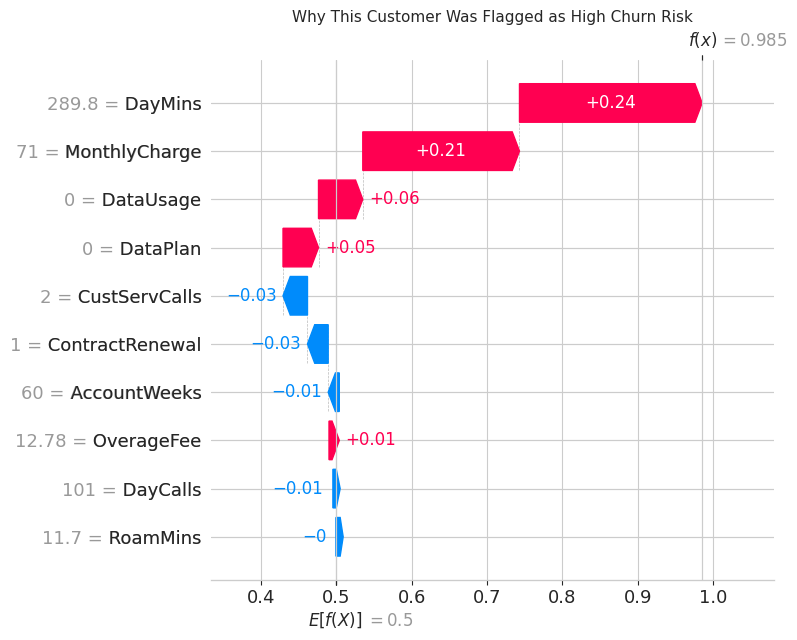

In [23]:
plt.figure(figsize=(10, 4))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[example_pos],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
        data=X_test.iloc[example_pos].values,
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title("Why This Customer Was Flagged as High Churn Risk", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/11_shap_individual_explanation.png", bbox_inches="tight")
plt.show()

## 8. Business Summary

### What drives churn, in plain terms

Based on the SHAP analysis, ranked by overall impact:

1. **Monthly charge** — Customers with higher monthly bills are meaningfully more likely to churn.
   Price sensitivity appears to be the single biggest lever.
2. **Customer service calls** — Customers who call support frequently (especially 4+ times) are at
   sharply elevated risk. This is a clear, actionable early-warning signal.
3. **Contract renewal** — Customers who have *not* recently renewed their contract churn far more often.
   This is intuitive but important to monitor systematically.
4. **Day minutes** — Heavy daytime usage is associated with higher churn, possibly reflecting
   high-usage customers who are more price-sensitive or more likely to be shopping competitor plans.
5. **Data plan / data usage** — Having a data plan and using data is mildly *protective* against churn —
   these customers appear stickier, possibly due to switching costs or bundled value.

### Recommended actions

- **Flag accounts with 4+ customer service calls** for proactive retention outreach — this is one of
  the cleanest, most actionable signals in the data.
- **Review pricing/discount strategy** for customers with high monthly charges, especially if they
  also show other risk factors.
- **Target contract renewal campaigns** at customers approaching renewal dates, with extra attention
  to high-usage customers.
- **Use the model's predicted probability** (not just the 0/1 label) to rank customers by risk and
  prioritize retention budget on the highest-risk, highest-value segment first.

### Model performance recap

In [24]:
summary_table = results_df.sort_values("F1 (churn)", ascending=False).copy()
summary_table.style.background_gradient(cmap="Blues", subset=metrics_to_plot)

,Precision (churn),Recall (churn),F1 (churn),ROC-AUC,PR-AUC
Model,,,,,
Random Forest (class_weight),0.649000,0.702000,0.675000,0.869000,0.724000
XGBoost (scale_pos_weight),0.646000,0.694000,0.669000,0.867000,0.736000
XGBoost (SMOTE),0.576000,0.719000,0.640000,0.860000,0.711000
Logistic Regression (class_weight),0.341000,0.727000,0.464000,0.814000,0.426000


**Final model: Random Forest (class_weight='balanced')**

- Catches roughly **7 in 10 customers** who actually go on to churn (recall).
- When it flags someone as at-risk, it's right about **65% of the time** (precision) — far better
  than the ~14.5% base rate, making retention outreach far more efficient than contacting customers at random.
- **ROC-AUC ≈ 0.87**, indicating strong overall ability to rank customers by churn risk.

This is a solid foundation for a retention program: the model won't catch every churner, but it
concentrates limited retention resources on the customers most likely to need them — a large
improvement over no targeting at all.

## Appendix: Saved Artifacts

All charts in this notebook are also saved to the `outputs/` folder as PNG files for use in
slide decks or reports:

- `01_class_imbalance.png`
- `02_feature_distributions.png`
- `03_correlation_with_churn.png`
- `04_model_comparison.png`
- `05_roc_curves.png`
- `06_confusion_matrix.png`
- `07_precision_recall_curve.png`
- `08_shap_summary.png`
- `09_shap_feature_importance.png`
- `10_shap_dependence.png`
- `11_shap_individual_explanation.png`